<a href="https://colab.research.google.com/github/habibiputrar/Habibi-Putra-Rizqullah_2411531001_ML2526/blob/main/Praktikum7/Decision_Tree_(Overfitting_%26_Tree_Depth).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dataset: Breast Cancer Dataset**

3.1 Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree



**3.2 Load Dataset**

In [15]:

# Load dataset dari raw GitHub
url = "https://raw.githubusercontent.com/habibiputrar/Habibi-Putra-Rizqullah_2411531001_ML2526/refs/heads/main/Praktikum6/breast-cancer.csv"
df = pd.read_csv(url)

# Encode target
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Ambil 2 fitur untuk visualisasi
X = df[['radius_mean', 'texture_mean']]
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**3.3 Decision Tree Default**

In [16]:
tree_default = DecisionTreeClassifier(random_state=42)
tree_default.fit(X_train, y_train)

y_train_pred = tree_default.predict(X_train)
y_test_pred = tree_default.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy :", accuracy_score(y_test, y_test_pred))



Train Accuracy: 1.0
Test Accuracy : 0.8771929824561403


**3.4 Uji Berbagai Nilai max_depth**

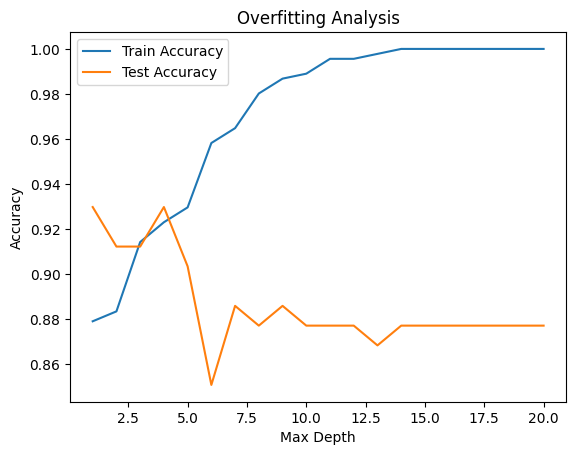

In [17]:
depths = range(1, 21)

train_acc = []
test_acc = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(depths, train_acc, label="Train Accuracy")
plt.plot(depths, test_acc, label="Test Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Overfitting Analysis")
plt.show()


**4.1 Bandingkan Kriteria**

In [13]:
tree_gini = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)
tree_entropy = DecisionTreeClassifier(criterion="entropy", max_depth=5, random_state=42)

tree_gini.fit(X_train, y_train)
tree_entropy.fit(X_train, y_train)

acc_gini = accuracy_score(y_test, tree_gini.predict(X_test))
acc_entropy = accuracy_score(y_test, tree_entropy.predict(X_test))

print("Accuracy (Gini):", acc_gini)
print("Accuracy (Entropy):", acc_entropy)



Accuracy (Gini): 0.9035087719298246
Accuracy (Entropy): 0.8771929824561403


**5.1 Plot Tree**

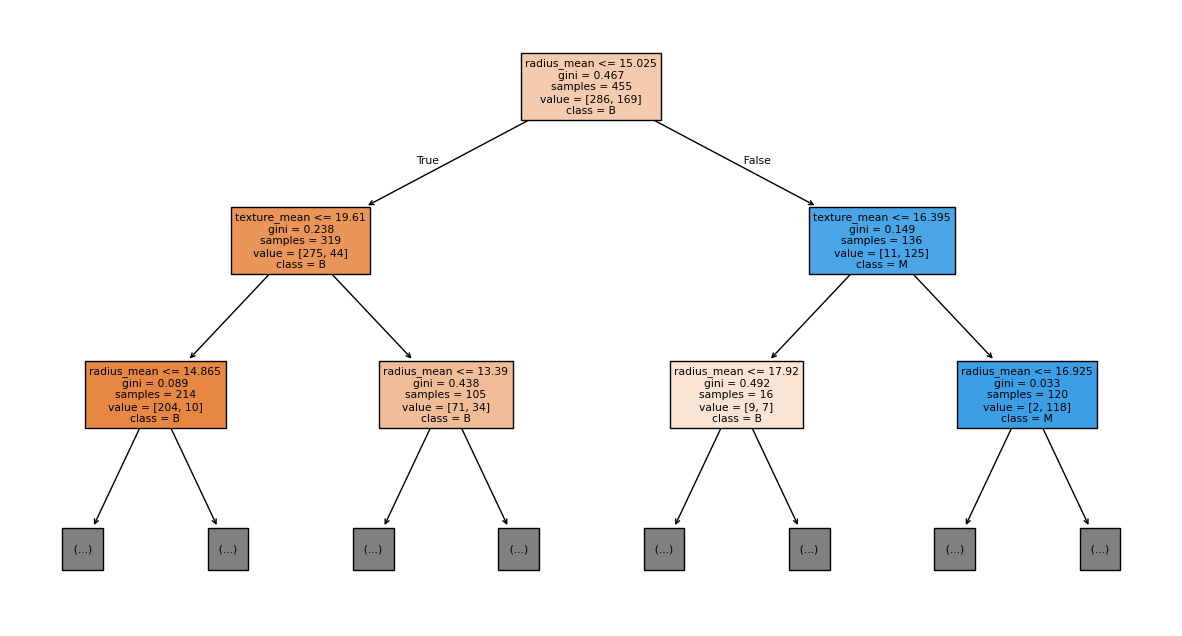

In [20]:
plt.figure(figsize=(15,8))
plot_tree(
    tree_gini,
    feature_names=X.columns,
    class_names=['B', 'M'],
    filled=True,
    max_depth=2
)
plt.show()

# **Tugas Individu**

**1. Uji max_depth hingga 30**

Best max_depth : 1
Best Test Acc  : 0.9298


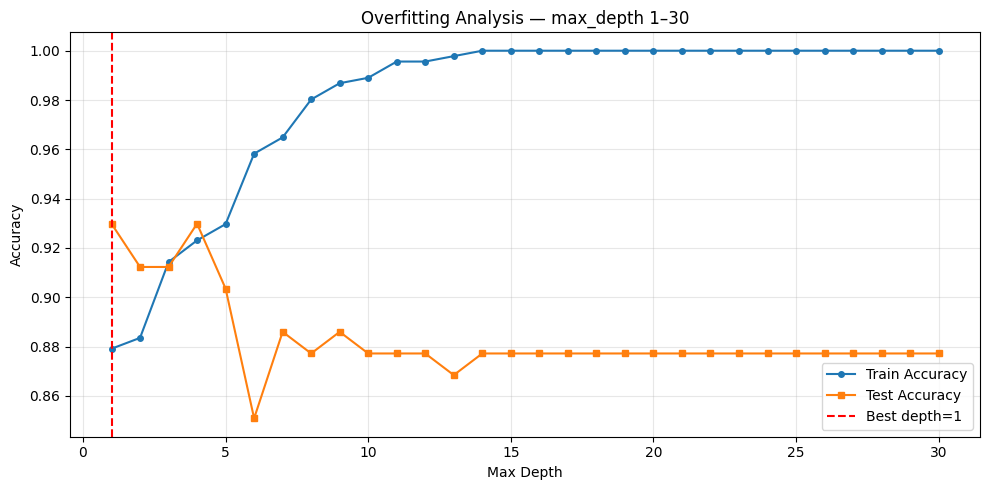


Tabel Depth vs Accuracy:
 Depth |  Train Acc |  Test Acc
--------------------------------
     1 |     0.8791 |    0.9298 <-- best
     2 |     0.8835 |    0.9123
     3 |     0.9143 |    0.9123
     4 |     0.9231 |    0.9298
     5 |     0.9297 |    0.9035
     6 |     0.9582 |    0.8509
     7 |     0.9648 |    0.8860
     8 |     0.9802 |    0.8772
     9 |     0.9868 |    0.8860
    10 |     0.9890 |    0.8772
    11 |     0.9956 |    0.8772
    12 |     0.9956 |    0.8772
    13 |     0.9978 |    0.8684
    14 |     1.0000 |    0.8772
    15 |     1.0000 |    0.8772
    16 |     1.0000 |    0.8772
    17 |     1.0000 |    0.8772
    18 |     1.0000 |    0.8772
    19 |     1.0000 |    0.8772
    20 |     1.0000 |    0.8772
    21 |     1.0000 |    0.8772
    22 |     1.0000 |    0.8772
    23 |     1.0000 |    0.8772
    24 |     1.0000 |    0.8772
    25 |     1.0000 |    0.8772
    26 |     1.0000 |    0.8772
    27 |     1.0000 |    0.8772
    28 |     1.0000 |    0.8772
    

In [21]:
depths = range(1, 31)
train_acc, test_acc = [], []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, m.predict(X_train)))
    test_acc.append(accuracy_score(y_test,  m.predict(X_test)))

best_depth = list(depths)[test_acc.index(max(test_acc))]
print(f"Best max_depth : {best_depth}")
print(f"Best Test Acc  : {max(test_acc):.4f}")

plt.figure(figsize=(10, 5))
plt.plot(depths, train_acc, label="Train Accuracy", marker="o", markersize=4)
plt.plot(depths, test_acc,  label="Test Accuracy",  marker="s", markersize=4)
plt.axvline(x=best_depth, color="red", linestyle="--", label=f"Best depth={best_depth}")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Overfitting Analysis — max_depth 1–30")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTabel Depth vs Accuracy:")
print(f"{'Depth':>6} | {'Train Acc':>10} | {'Test Acc':>9}")
print("-" * 32)
for d, tr, te in zip(depths, train_acc, test_acc):
    mark = " <-- best" if d == best_depth else ""
    print(f"{d:>6} | {tr:>10.4f} | {te:>9.4f}{mark}")

**2. min_samples_split & min_samples_leaf**

In [22]:
results = []
for mss in [2, 5, 10, 20]:
    for msl in [1, 2, 5, 10]:
        m = DecisionTreeClassifier(
            max_depth=best_depth,
            min_samples_split=mss,
            min_samples_leaf=msl,
            random_state=42
        )
        m.fit(X_train, y_train)
        results.append({
            "min_samples_split": mss,
            "min_samples_leaf" : msl,
            "train_acc": round(accuracy_score(y_train, m.predict(X_train)), 4),
            "test_acc" : round(accuracy_score(y_test,  m.predict(X_test)),  4),
        })

df_res = pd.DataFrame(results).sort_values("test_acc", ascending=False)
print("\nTop 10 kombinasi min_samples_split & min_samples_leaf:")
print(df_res.head(10).to_string(index=False))

best_row = df_res.iloc[0]
best_mss = int(best_row["min_samples_split"])
best_msl = int(best_row["min_samples_leaf"])


Top 10 kombinasi min_samples_split & min_samples_leaf:
 min_samples_split  min_samples_leaf  train_acc  test_acc
                 2                 1     0.8791    0.9298
                 2                 2     0.8791    0.9298
                 2                 5     0.8791    0.9298
                 2                10     0.8791    0.9298
                 5                 1     0.8791    0.9298
                 5                 2     0.8791    0.9298
                 5                 5     0.8791    0.9298
                 5                10     0.8791    0.9298
                10                 1     0.8791    0.9298
                10                 2     0.8791    0.9298


**3. Bandingkan dengan Logistic Regression**

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

tree_best = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_split=best_mss,
    min_samples_leaf=best_msl,
    random_state=42
)
tree_best.fit(X_train, y_train)
acc_tree = accuracy_score(y_test, tree_best.predict(X_test))

lr = LogisticRegression(max_iter=10000, random_state=42)
lr.fit(X_train_sc, y_train)
acc_lr = accuracy_score(y_test, lr.predict(X_test_sc))

print("\n=== Perbandingan Model ===")
print(f"Decision Tree (best params) : {acc_tree:.4f}")
print(f"Logistic Regression         : {acc_lr:.4f}")


=== Perbandingan Model ===
Decision Tree (best params) : 0.9298
Logistic Regression         : 0.9035


**4. 5-Fold Cross Validation**

In [26]:
from sklearn.model_selection import cross_val_score

models_cv = {
    "Decision Tree (best)"  : DecisionTreeClassifier(max_depth=best_depth, min_samples_split=best_mss, min_samples_leaf=best_msl, random_state=42),
    "Logistic Regression"   : LogisticRegression(max_iter=10000, random_state=42),
}

print("\n=== 5-Fold Cross Validation ===")
print(f"{'Model':<30} | {'Mean':>6} | {'Std':>6}")
print("-" * 48)
for name, mdl in models_cv.items():
    X_cv = scaler.fit_transform(X) if "Logistic" in name else X
    cv = cross_val_score(mdl, X_cv, y, cv=5, scoring="accuracy")
    print(f"{name:<30} | {cv.mean():.4f} | {cv.std():.4f}")


=== 5-Fold Cross Validation ===
Model                          |   Mean |    Std
------------------------------------------------
Decision Tree (best)           | 0.8893 | 0.0459
Logistic Regression            | 0.8858 | 0.0282


In [28]:
from sklearn.metrics import classification_report

print("\n=== Classification Report (Decision Tree) ===")
print(classification_report(y_test, tree_best.predict(X_test), target_names=['B', 'M']))


=== Classification Report (Decision Tree) ===
              precision    recall  f1-score   support

           B       0.91      0.99      0.95        71
           M       0.97      0.84      0.90        43

    accuracy                           0.93       114
   macro avg       0.94      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114



**Feature Importance**

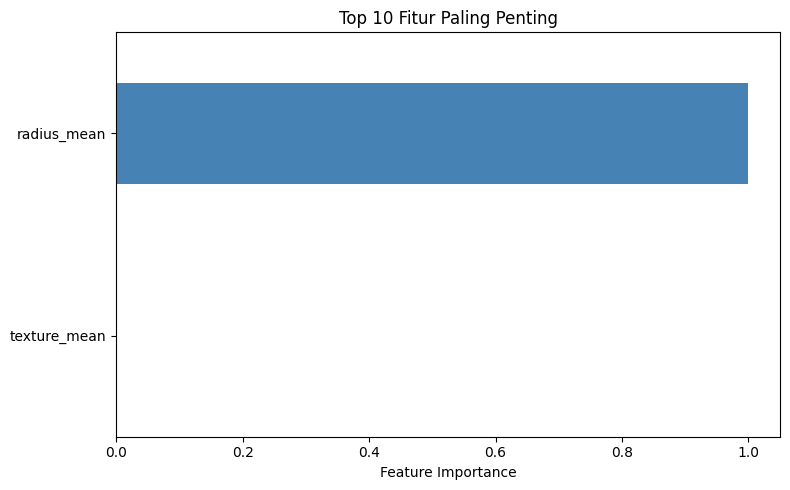

In [29]:
feat_imp = pd.Series(tree_best.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind="barh", color="steelblue")
plt.xlabel("Feature Importance")
plt.title("Top 10 Fitur Paling Penting")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()